# Proyecto dataset de Titanic

Este proyecto tiene por objetivo analizar datos sobre los registros de sobrevivientes del titanic. Utilizando como base de información los archivos que se encuentran en https://www.kaggle.com/competitions/titanic/data. El fin es poder predecir mediante sus datos cuales son las personas que sobreviven o no. Además de identificar cuales son los factores que mas influyen en las probabilidades de sobrevivir.

Algunas explicaciones de columnas:  
- Pclass = Clase del ticket: 1st, 2nd, 3rd
- SibSp = Número de hermanos o cónyugues arriba del titanic
- Parch = Número de familiares o hijos arriba del titanic
- Ticket = Número del ticket
- Fare = Tarifa
- Cabin = Número de la cabina
- Embarked = Puerto de embarcación: C(Cherbourg), Q(Queenstown), S(Southampton)

### Configurar raíz del proyecto para poder utilizar los recursos de src

In [1]:
import sys
from pathlib import Path
root = str(Path("..").resolve())
if root not in sys.path:
    sys.path.insert(0, root)

### Imports necesarios

In [2]:
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score, f1_score, accuracy_score, precision_score
from src.data_cleaning import rellenar_age_median, eliminar_cabin, rellenar_embarked, eliminar_columnas_innecesarias, rellenar_fare_median, eliminar_columnas_ml
from src.feature_engineering import sex_map, one_hot_embarked, family_size_isAlone, one_hot_titles
from src.visualization import create_fig_pie__sobrevivientes
from src.utils import contar_sobrevivientes

### Carga de datos

In [3]:
ruta_train_csv = r'../data/raw/train.csv'
df_inicial_train = pd.read_csv(ruta_train_csv)

### Visualización inicial

DataFrame cargado inicial:

In [4]:
print(f'Datos iniciales:\n{df_inicial_train}')

Datos iniciales:
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 .

Info del DataFrame y describe

In [5]:
df_inicial_train.info()
print(f'\nDescribe:\n{df_inicial_train.describe()}')

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Describe:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.83

### EDA

Rellenar valores de Age con la mediana

In [6]:
df_edad_rellenada = rellenar_age_median(df_inicial_train)
print(f'DataFrame con Age completo:\n{df_edad_rellenada}')
df_edad_rellenada.info()

DataFrame con Age completo:
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                       

Quitar la columna Cabin, para este ejercicio no se considerará debido a su cantidad de valores distintos, no se podría clasificar

In [7]:
df_drop_cabin = eliminar_cabin(df_edad_rellenada)

Rellenar los valores faltantes de Embarked, son pocos pero esto es para tener un DataFrame mas limpio y fácil de trabajar. Se aplica mode para obtener la moda, lo cual se puede repetir asi que da una serie, entonces eligimos el primer valor

In [8]:
df_procesado = rellenar_embarked(df_drop_cabin)
df_procesado.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


### Creación de gráficos para entendimiento

Crear columna de sobrevivientes en palabras, esto para crear un gráfico mas entendible y amigable

In [9]:
df_procesado['Sobreviviente'] = df_procesado['Survived'].map({0: 'No sobrevivió', 1: 'Sobrevivió'})
print(f'DataFrame con columna de sobreviviente o no:\n{df_procesado}')

DataFrame con columna de sobreviviente o no:
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                      

1. Generar DataFrame solo de mujeres, para contar cuantos sobrevivientes y no sobrevivientes hay. Luego mapear colores para que en el gráfico se vean colores especificos dependiendo si es sobreviviente o no.

In [10]:
df_mujeres = df_procesado[df_procesado['Sex'] == 'female']
cuenta_sobrevivientes_mujeres = contar_sobrevivientes(df_mujeres)
print(cuenta_sobrevivientes_mujeres)




   Sobreviviente  count
0     Sobrevivió    233
1  No sobrevivió     81


1.1 Gráfico de sobrevivientes mujeres

In [11]:
fig_pie_sobrevivientes_female = create_fig_pie__sobrevivientes(cuenta_sobrevivientes_mujeres)

fig_pie_sobrevivientes_female.show()

2. Realizar misma accion para los hombres

In [12]:
df_hombres = df_procesado[df_procesado['Sex'] == 'male']
cuenta_sobrevivientes_hombres = df_hombres['Sobreviviente'].value_counts()
cuenta_sobrevivientes_hombres = cuenta_sobrevivientes_hombres.reset_index()
print(cuenta_sobrevivientes_hombres)

   Sobreviviente  count
0  No sobrevivió    468
1     Sobrevivió    109


2.2 Gráfico de sobrevivientes hombres

In [13]:
fig_pie_sobrevivientes_hombres = create_fig_pie__sobrevivientes(cuenta_sobrevivientes_hombres)


fig_pie_sobrevivientes_hombres.show()

3. Ahora buscar taza de sobrevivientes por rangos de edad, primero utilizar una cantidad considerable (mayor a 100) registros por cada grupo para identificar si hay alguna tendencia y que sea fidedigna

In [14]:
df_jovenes_debajo_18 = df_procesado[df_procesado['Age'] <= 18]
df_adultos_18_40 = df_procesado[(df_procesado['Age'] > 18) & (df_procesado['Age'] <= 40)]
df_adultos_sobre_40 = df_procesado[df_procesado['Age'] > 40]
print(len(df_jovenes_debajo_18))
print(len(df_adultos_18_40))
print(len(df_adultos_sobre_40))

139
602
150


3.1 Crear y manejar datos para ver sobrevivientes jovenes

In [15]:
sobrevivientes_debajo_18 = df_jovenes_debajo_18['Sobreviviente'].value_counts()
sobrevivientes_debajo_18 = sobrevivientes_debajo_18.reset_index()
print(sobrevivientes_debajo_18)


   Sobreviviente  count
0     Sobrevivió     70
1  No sobrevivió     69


3.2 Gráfico de sobrevivientes "jovenes"

In [16]:
fig_pie_sobrevivientes_jovenes = create_fig_pie__sobrevivientes(sobrevivientes_debajo_18)

fig_pie_sobrevivientes_jovenes.show()

3.3 Realizar lo mismo para los pasajeros con edad entre 18 y 40 años

In [17]:
sobrevivientes_18_40 = df_adultos_18_40['Sobreviviente'].value_counts()
sobrevivientes_18_40 = sobrevivientes_18_40.reset_index()
print(sobrevivientes_18_40)

   Sobreviviente  count
0  No sobrevivió    385
1     Sobrevivió    217


3.4 Gráfico sobrevivientes entre 18 y 40 años

In [18]:
fig_pie_sobrevivientes_18_40 = create_fig_pie__sobrevivientes(sobrevivientes_18_40)

fig_pie_sobrevivientes_18_40.show()

3.5 Realizar lo mismo para pasajeros mayores a 40 años

In [19]:
sobrevivientes_mayores_40 = df_adultos_sobre_40['Sobreviviente'].value_counts()
sobrevivientes_mayores_40 = sobrevivientes_mayores_40.reset_index()
print(sobrevivientes_mayores_40)


   Sobreviviente  count
0  No sobrevivió     95
1     Sobrevivió     55


3.6 Gráfico para sobrevivientes mayores a 40 años

In [20]:
fig_pie_sobrevivientes_mayores_40 = create_fig_pie__sobrevivientes(sobrevivientes_mayores_40)

fig_pie_sobrevivientes_mayores_40.show()

4. Para este apartado analizar si el precio de la tarifa (Fare) puede tener que ver con la sobrevivencia, pero antes saber que se puede conocer como Fare alto o bajo, para ello realizar un histograma

In [21]:
fig_histograma_fares = px.histogram(
    df_procesado,
    x='Fare'
)
fig_histograma_fares.show()

4.1 Ahora conociendo los datos de que casi todos los pasajeros tenian un fare de 15 o menor, se separa por ese número

In [22]:
df_fare_bajo = df_procesado[df_procesado['Fare'] <= 15]
cuenta_sobrevivientes_fare_bajo = df_fare_bajo['Sobreviviente'].value_counts()
cuenta_sobrevivientes_fare_bajo = cuenta_sobrevivientes_fare_bajo.reset_index()
print(cuenta_sobrevivientes_fare_bajo)



   Sobreviviente  count
0  No sobrevivió    344
1     Sobrevivió    114


4.2 Gráfico para sobrevivientes de "Fare" bajo

In [23]:
fig_sobrevivientes_fare_bajo = create_fig_pie__sobrevivientes(cuenta_sobrevivientes_fare_bajo)


fig_sobrevivientes_fare_bajo.show()

4.3 Crear DataFrame con registros con "Fare" mas alto

In [24]:
df_fare_alto = df_procesado[df_procesado['Fare'] > 15]
cuenta_sobrevivientes_fare_alto = df_fare_alto['Sobreviviente'].value_counts()
cuenta_sobrevivientes_fare_alto = cuenta_sobrevivientes_fare_alto.reset_index()
print(cuenta_sobrevivientes_fare_alto)


   Sobreviviente  count
0     Sobrevivió    228
1  No sobrevivió    205


4.4 Gráfico para pasajeros con "Fare" mas alto

In [25]:
fig_sobrevivientes_fare_alto = create_fig_pie__sobrevivientes(cuenta_sobrevivientes_fare_alto)

fig_sobrevivientes_fare_alto.show()

5. Generar DataFrame con la información necesaria para ver si la "Pclass" tiene que ver con la sobrevivencia

5.1 Primero obtener datos de "Pclass" = 1

In [26]:
df_pclass_1 = df_procesado[df_procesado['Pclass'] == 1]
sobrevivientes_pclass_1 = df_pclass_1['Sobreviviente'].value_counts()
sobrevivientes_pclass_1 = sobrevivientes_pclass_1.reset_index()
print(sobrevivientes_pclass_1)

   Sobreviviente  count
0     Sobrevivió    136
1  No sobrevivió     80


5.2 Gráfico de sobrevivientes en Pclass = 1

In [27]:
fig_pie_sobrevivientes_pclass_1 = create_fig_pie__sobrevivientes(sobrevivientes_pclass_1)

fig_pie_sobrevivientes_pclass_1.show()

5.3 Datos para Pclass = 2

In [28]:
df_pclass_2 = df_procesado[df_procesado['Pclass'] == 2]
sobrevivientes_pclass_2 = df_pclass_2['Sobreviviente'].value_counts()
sobrevivientes_pclass_2 = sobrevivientes_pclass_2.reset_index()
print(sobrevivientes_pclass_2)

   Sobreviviente  count
0  No sobrevivió     97
1     Sobrevivió     87


5.4 Gráfico sobrevivientes en Pclass = 2

In [29]:
fig_pie_sobrevivientes_pclass_2 = create_fig_pie__sobrevivientes(sobrevivientes_pclass_2)

fig_pie_sobrevivientes_pclass_2.show()

5.5 Datos para Pclass = 3

In [30]:
df_pclass_3 = df_procesado[df_procesado['Pclass'] == 3]
sobrevivientes_pclass_3 = df_pclass_3['Sobreviviente'].value_counts()
sobrevivientes_pclass_3 = sobrevivientes_pclass_3.reset_index()
print(sobrevivientes_pclass_3)

   Sobreviviente  count
0  No sobrevivió    372
1     Sobrevivió    119


5.6 Gráfico sobrevivientes en Pclass = 3

In [31]:
fig_pie_sobrevivientes_pclass_3 = create_fig_pie__sobrevivientes(sobrevivientes_pclass_3)

fig_pie_sobrevivientes_pclass_3.show()

6. Obtener información para saber si el lugar donde fue embarcado tiene relación

6.1 Info de Embarked = C

In [32]:
df_embarked_c = df_procesado[df_procesado['Embarked'] == 'C']
sobrevivientes_embarked_c = df_embarked_c['Sobreviviente'].value_counts()
sobrevivientes_embarked_c = sobrevivientes_embarked_c.reset_index()
print(sobrevivientes_embarked_c)

   Sobreviviente  count
0     Sobrevivió     93
1  No sobrevivió     75


6.2 Gráfico sobrevivientes Embarked = C

In [33]:
fig_pie_sobrevivientes_embarked_c = create_fig_pie__sobrevivientes(sobrevivientes_embarked_c)

fig_pie_sobrevivientes_embarked_c.show()

6.4 Info Embarked = Q

In [34]:
df_embarked_q = df_procesado[df_procesado['Embarked'] == 'Q']
sobrevivientes_embarked_q = df_embarked_q['Sobreviviente'].value_counts()
sobrevivientes_embarked_q = sobrevivientes_embarked_q.reset_index()
print(sobrevivientes_embarked_q)

   Sobreviviente  count
0  No sobrevivió     47
1     Sobrevivió     30


6.5 Gráfico sobrevivientes Embarked = Q

In [35]:
fig_pie_sobrevivientes_embarked_q = create_fig_pie__sobrevivientes(sobrevivientes_embarked_q)

fig_pie_sobrevivientes_embarked_q.show()

6.6 Info Embarked = S

In [36]:
df_embarked_s = df_procesado[df_procesado['Embarked'] == 'S']
sobrevivientes_embarked_s = df_embarked_s['Sobreviviente'].value_counts()
sobrevivientes_embarked_s = sobrevivientes_embarked_s.reset_index()
print(sobrevivientes_embarked_s)

   Sobreviviente  count
0  No sobrevivió    427
1     Sobrevivió    219


6.7 Gráfico sobrevivientes Embarked = S

In [37]:
fig_pie_sobrevivientes_embarked_s = create_fig_pie__sobrevivientes(sobrevivientes_embarked_s)

fig_pie_sobrevivientes_embarked_s.show()

### Machine Learning

Para el trabajo con machine learning la idea es poder aprender con los datos que tenemos y después poder predecir información

1. Primero quitaremos columnas que no vamos a utilizar, cambiar los valores de Sex a 0 y 1. Además lógica para crear 3 columnas, una para cada tipo de Embarked, marcando 1 en donde corresponda.

In [38]:
df_ml = df_procesado.drop(columns=['PassengerId', 'Ticket', 'Sobreviviente'])

df_ml = sex_map(df_ml)
df_ml = one_hot_embarked(df_ml)

print(df_ml)

     Survived  Pclass                                               Name  Sex  \
0           0       3                            Braund, Mr. Owen Harris    1   
1           1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0   
2           1       3                             Heikkinen, Miss. Laina    0   
3           1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0   
4           0       3                           Allen, Mr. William Henry    1   
..        ...     ...                                                ...  ...   
886         0       2                              Montvila, Rev. Juozas    1   
887         1       1                       Graham, Miss. Margaret Edith    0   
888         0       3           Johnston, Miss. Catherine Helen "Carrie"    0   
889         1       1                              Behr, Mr. Karl Howell    1   
890         0       3                                Dooley, Mr. Patrick    1   

      Age  SibSp  Parch    

2. Obtener datos de con cuentas personas iba, además de si esta sólo o no

In [39]:
df_ml = family_size_isAlone(df_ml)

print(df_ml)

     Survived  Pclass                                               Name  Sex  \
0           0       3                            Braund, Mr. Owen Harris    1   
1           1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0   
2           1       3                             Heikkinen, Miss. Laina    0   
3           1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0   
4           0       3                           Allen, Mr. William Henry    1   
..        ...     ...                                                ...  ...   
886         0       2                              Montvila, Rev. Juozas    1   
887         1       1                       Graham, Miss. Margaret Edith    0   
888         0       3           Johnston, Miss. Catherine Helen "Carrie"    0   
889         1       1                              Behr, Mr. Karl Howell    1   
890         0       3                                Dooley, Mr. Patrick    1   

      Age  SibSp  Parch    

3. Obtener datos en forma de One-Hot-Encoding de sus títulos

In [40]:
df_ml = one_hot_titles(df_ml)

print(df_ml)


     Survived  Pclass                                               Name  Sex  \
0           0       3                            Braund, Mr. Owen Harris    1   
1           1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0   
2           1       3                             Heikkinen, Miss. Laina    0   
3           1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0   
4           0       3                           Allen, Mr. William Henry    1   
..        ...     ...                                                ...  ...   
886         0       2                              Montvila, Rev. Juozas    1   
887         1       1                       Graham, Miss. Margaret Edith    0   
888         0       3           Johnston, Miss. Catherine Helen "Carrie"    0   
889         1       1                              Behr, Mr. Karl Howell    1   
890         0       3                                Dooley, Mr. Patrick    1   

      Age  SibSp  Parch    

4. Separar los datos para entrenamiento y pruebas. Stratify con "y" para que la cantidad de "Survived" se separe de manera parecia y no tengamos un entrenamiento con demasiados registros de sobrevivientes o demasiados no sobrevivientes (que sea parejo)    
Ademas quitamos una columna de Embarked para evitar dummy's, ya que es obvio que si Embarked_C=0 y Embarked_S=0 por lógica el Embarked_Q seria 1, no tiene sentido colocar otra columna señalandolo, ya que las 3 columnas dependen entre sí.

In [41]:
X = df_ml.drop(columns=['Survived', 'Embarked_Q', 'Title', 'Name'])
y = df_ml['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=7, stratify=y)




5. Escalar datos necesarios, recordar que en los modelos de ML datos que son demasiado diferentes entre si provocan que al modelo le cueste mas converger. Esto se hace despues de separar train y test para que el escalador haga fit(aprenda) a escalar con los datos de entrenamiento y luego solo transforme los datos del test utilizando la forma aprendida.  
Además se ocupa 1 objeto escalador que guarda la forma de escalar de "Age" y "Fare" en ese orden, entonces cuando se transforma es necesario escalar en el mismo orden ya que va a aplicar lo aprendido en el orden de "Age" y "Fare" respectivamente

In [42]:
scaler_standardscaler = StandardScaler()
X_train[['Age', 'Fare', 'tamanio_familia']] = scaler_standardscaler.fit_transform(X_train[['Age', 'Fare', 'tamanio_familia']])
X_test[['Age', 'Fare', 'tamanio_familia']] = scaler_standardscaler.transform(X_test[['Age', 'Fare', 'tamanio_familia']])

In [43]:
print(X_test)

     Pclass  Sex       Age  SibSp  Parch      Fare  Embarked_C  Embarked_S  \
7         3    1 -2.118394      3      1 -0.248778           0           1   
874       2    0 -0.118316      1      0 -0.186575           1           0   
720       2    0 -1.810690      0      1  0.004818           0           1   
513       1    0  1.881762      1      0  0.566237           1           0   
459       3    1 -0.118316      0      0 -0.532146           0           0   
..      ...  ...       ...    ...    ...       ...         ...         ...   
178       2    1  0.035536      0      0 -0.420500           0           1   
603       3    1  1.112501      0      0 -0.525766           0           1   
111       3    0 -1.156818      1      0 -0.389575           1           0   
287       3    1 -0.579873      0      0 -0.529045           0           1   
798       3    1  0.035536      0      0 -0.543221           1           0   

     tamanio_familia  isAlone  isMr  isMrs  isMiss  isMaster  i

6. Aplicación de SMOTE lo cual sirve para poder tener un mejor balance en los datos, ya que titanic esta ligeramente desbalanceado (mas casos de no sobrevientes)

In [44]:
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

6. Crear y entrenar modelo

In [45]:
model_logistic = LogisticRegression(
    max_iter=2000, # Iteraciones altas, lo que pasa es que con bajas no llega a una generalización por multiples factores posibles
    random_state=7
)
model_logistic.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",7
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

8. Realizar predicciones

In [46]:
y_pred = model_logistic.predict(X_test)

9. Medir modelo

In [47]:
accuracy_logistic = accuracy_score(y_test, y_pred)
precision_logistic = precision_score(y_test, y_pred)
recall_logistic = recall_score(y_test, y_pred)
f1_logistic = f1_score(y_test, y_pred)
ptj_cross_val_logistic = cross_val_score(model_logistic, X, y, cv=5)

print(f'Accuracy: {accuracy_logistic}')
print(f'Precision: {precision_logistic}')
print(f'Recall: {recall_logistic}')
print(f'F1: {f1_logistic}')
print(f'Cross validation: {ptj_cross_val_logistic.mean()}')

Accuracy: 0.7877094972067039
Precision: 0.7183098591549296
Recall: 0.7391304347826086
F1: 0.7285714285714285
Cross validation: 0.8204255853367648


10. Matriz de confusión

[[90 20]
 [18 51]]


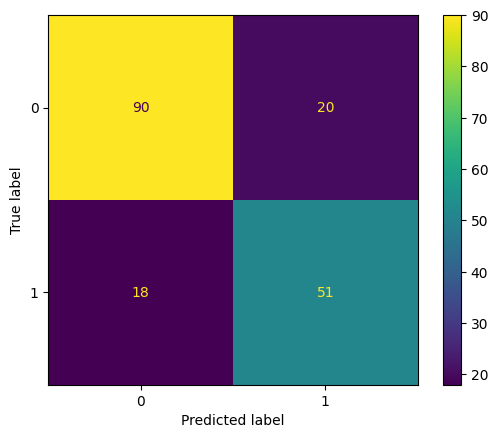

In [48]:
matriz_confusion = confusion_matrix(y_test, y_pred)
print(matriz_confusion)
display_matriz_confusion = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion)
print(display_matriz_confusion)
display_matriz_confusion.plot()

11. Probar modelo con elementos del test.csv, ojo que solo es una prueba de predicciones no se comprueban si son correctas  
Para ello primero obtener la información

In [49]:
test_data_inicial = pd.read_csv('../data/raw/test.csv')
print(test_data_inicial)

     PassengerId  Pclass                                          Name  \
0            892       3                              Kelly, Mr. James   
1            893       3              Wilkes, Mrs. James (Ellen Needs)   
2            894       2                     Myles, Mr. Thomas Francis   
3            895       3                              Wirz, Mr. Albert   
4            896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)   
..           ...     ...                                           ...   
413         1305       3                            Spector, Mr. Woolf   
414         1306       1                  Oliva y Ocana, Dona. Fermina   
415         1307       3                  Saether, Mr. Simon Sivertsen   
416         1308       3                           Ware, Mr. Frederick   
417         1309       3                      Peter, Master. Michael J   

        Sex   Age  SibSp  Parch              Ticket      Fare Cabin Embarked  
0      male  34.5      0      0 

12. Ver valores faltantes

In [50]:
test_data_inicial.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


13. Limpieza de datos

In [51]:
test_rellenado = rellenar_age_median(test_data_inicial)
test_rellenado = eliminar_cabin(test_rellenado)
df_test_procesado = rellenar_embarked(test_rellenado)
df_test_procesado = eliminar_columnas_innecesarias(df_test_procesado)
df_test_procesado = rellenar_fare_median(df_test_procesado)
print(df_test_procesado)
df_test_procesado.info()


     Pclass                                          Name     Sex   Age  \
0         3                              Kelly, Mr. James    male  34.5   
1         3              Wilkes, Mrs. James (Ellen Needs)  female  47.0   
2         2                     Myles, Mr. Thomas Francis    male  62.0   
3         3                              Wirz, Mr. Albert    male  27.0   
4         3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0   
..      ...                                           ...     ...   ...   
413       3                            Spector, Mr. Woolf    male  27.0   
414       1                  Oliva y Ocana, Dona. Fermina  female  39.0   
415       3                  Saether, Mr. Simon Sivertsen    male  38.5   
416       3                           Ware, Mr. Frederick    male  27.0   
417       3                      Peter, Master. Michael J    male  27.0   

     SibSp  Parch      Fare Embarked  
0        0      0    7.8292        Q  
1        1      0    

14. Feature engineering (Sexo a binario/One-hot embarked/Tamaño de la familia y si va solo/One-hot titulos/Eliminar columnas)

In [52]:
df_ml = sex_map(df_test_procesado)
df_ml = one_hot_embarked(df_ml)
df_ml = family_size_isAlone(df_ml)
df_ml = one_hot_titles(df_ml)
df_ml = eliminar_columnas_ml(df_ml)

In [53]:
print(df_ml)

     Pclass  Sex   Age  SibSp  Parch      Fare  Embarked_C  Embarked_S  \
0         3    1  34.5      0      0    7.8292           0           0   
1         3    0  47.0      1      0    7.0000           0           1   
2         2    1  62.0      0      0    9.6875           0           0   
3         3    1  27.0      0      0    8.6625           0           1   
4         3    0  22.0      1      1   12.2875           0           1   
..      ...  ...   ...    ...    ...       ...         ...         ...   
413       3    1  27.0      0      0    8.0500           0           1   
414       1    0  39.0      0      0  108.9000           1           0   
415       3    1  38.5      0      0    7.2500           0           1   
416       3    1  27.0      0      0    8.0500           0           1   
417       3    1  27.0      1      1   22.3583           1           0   

     tamanio_familia  isAlone  isMr  isMrs  isMiss  isMaster  isRare  
0                  1        1     1     

15. Escalar los datos de Age y Fare

In [54]:
df_ml[['Age', 'Fare', 'tamanio_familia']] = scaler_standardscaler.transform(df_ml[['Age', 'Fare', 'tamanio_familia']])

In [55]:
print(df_ml)

     Pclass  Sex       Age  SibSp  Parch      Fare  Embarked_C  Embarked_S  \
0         3    1  0.381704      0      0 -0.530461           0           0   
1         3    0  1.343280      1      0 -0.548095           0           1   
2         2    1  2.497171      0      0 -0.490943           0           0   
3         3    1 -0.195242      0      0 -0.512741           0           1   
4         3    0 -0.579873      1      1 -0.435652           0           1   
..      ...  ...       ...    ...    ...       ...         ...         ...   
413       3    1 -0.195242      0      0 -0.525766           0           1   
414       1    0  0.727871      0      0  1.618898           1           0   
415       3    1  0.689408      0      0 -0.542779           0           1   
416       3    1 -0.195242      0      0 -0.525766           0           1   
417       3    1 -0.195242      1      1 -0.221487           1           0   

     tamanio_familia  isAlone  isMr  isMrs  isMiss  isMaster  i

16. Realizar predicciónes con el modelo entrenado en fase anterior

In [56]:
y_pred_testcsv = model_logistic.predict(df_ml)

1. Inicio con pruebas de RandomForest, primero instanciar un objeto RandomForestClassifier

In [57]:
model_random_forest = RandomForestClassifier(random_state=7)

2. Ocupar GridSearchCV para saber con que parámetros funcionaría mejor RandomForestClassifier

In [58]:
parametros = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [4, 5, 6, 7, 8],
    'criterion': ['gini', 'entropy']
}

grid_search_randforest = GridSearchCV(estimator=model_random_forest,
                                      param_grid=parametros,
                                      cv=5,
                                      scoring='accuracy'
                                      )

2. Entrenar modelo con los datos que ya se han calculado anteriormente

In [59]:
grid_search_randforest.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=7)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [4, 5, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

3. Predecir con los los test

In [60]:
y_pred_randforest = grid_search_randforest.predict(X_test)

4. Medir modelo RandomForestClassifier

In [61]:
accuracy_randomforest = accuracy_score(y_test, y_pred_randforest)
precision_randomforest = precision_score(y_test, y_pred_randforest)
recall_randomforest = recall_score(y_test, y_pred_randforest)
f1_randomforest = f1_score(y_test, y_pred_randforest)
ptj_cross_val_logistic = cross_val_score(model_logistic, X, y, cv=5)

print(f'Accuracy: {accuracy_randomforest}')
print(f'Precision: {precision_randomforest}')
print(f'Recall: {recall_randomforest}')
print(f'F1: {f1_randomforest}')
print(f'Cross validation: {ptj_cross_val_logistic.mean()}')

Accuracy: 0.8379888268156425
Precision: 0.803030303030303
Recall: 0.7681159420289855
F1: 0.7851851851851852
Cross validation: 0.8204255853367648


5. Matriz de confusión

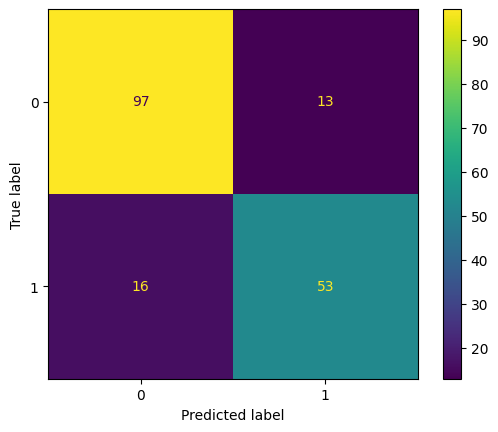

In [62]:
matriz_confusion_randforest = confusion_matrix(y_test, y_pred_randforest)
display_matriz_confusion_rand_forest = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion_randforest)
display_matriz_confusion_rand_forest.plot()